In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [23]:
df= sns.load_dataset('titanic')
df.head(10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [24]:
df.shape

(891, 15)

In [25]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [26]:
df= df.dropna(subset=['age'])

In [27]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           530
embark_town      2
alive            0
alone            0
dtype: int64


In [28]:
def categorize_fare(fare, fare_ranges):
  if fare<= fare_ranges[0]:
    return 0 #katergoria cenowa niska
  elif fare <= fare_ranges[1]:
    return 1 #kategoria cenowa średnia
  else:
    return 2 #kategoria cenowa wysoka

In [29]:
min_fare= df['fare'].min()
max_fare= df['fare'].max()
fare_step= (max_fare-min_fare)/3
fare_ranges= [min_fare+fare_step, min_fare + 2*fare_step]


In [30]:
print('Przedziały cenowe biletów:')
print(f'Niska cena:  {min_fare:.2f} - {fare_ranges[0]:.2f}')
print(f'Średnia cena:  {fare_ranges[0]:.2f} - {fare_ranges[1]:.2f}')
print(f'Średnia cena:  {fare_ranges[1]:.2f} - {max_fare:.2f}')


Przedziały cenowe biletów:
Niska cena:  0.00 - 170.78
Średnia cena:  170.78 - 341.55
Średnia cena:  341.55 - 512.33


In [31]:
selected_features= [ 'who', 'pclass', 'age', 'fare_category']

In [32]:
df_model= df.copy()
df_model['who']= df_model['who'].map({'man' : 0, 'woman' : 1, 'child': 2})
df_model['fare_category']= df_model['fare'].apply(lambda x: categorize_fare(x, fare_ranges))

In [33]:
X= df_model[selected_features]
y= df_model['survived']

In [34]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
scaler= StandardScaler()

In [36]:
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [37]:
df.head(50)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False


In [38]:
model= LogisticRegression(
    random_state=42,
    C=0.2
)
model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.2, random_state=42)

In [40]:
y_pred=model.predict(X_test_scaled)
accuracy= accuracy_score(y_test, y_pred)
print(f'dokładność: {accuracy:.3f}')
print(classification_report(y_test, y_pred))

dokładność: 0.783
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        87
           1       0.74      0.70      0.72        56

    accuracy                           0.78       143
   macro avg       0.77      0.77      0.77       143
weighted avg       0.78      0.78      0.78       143



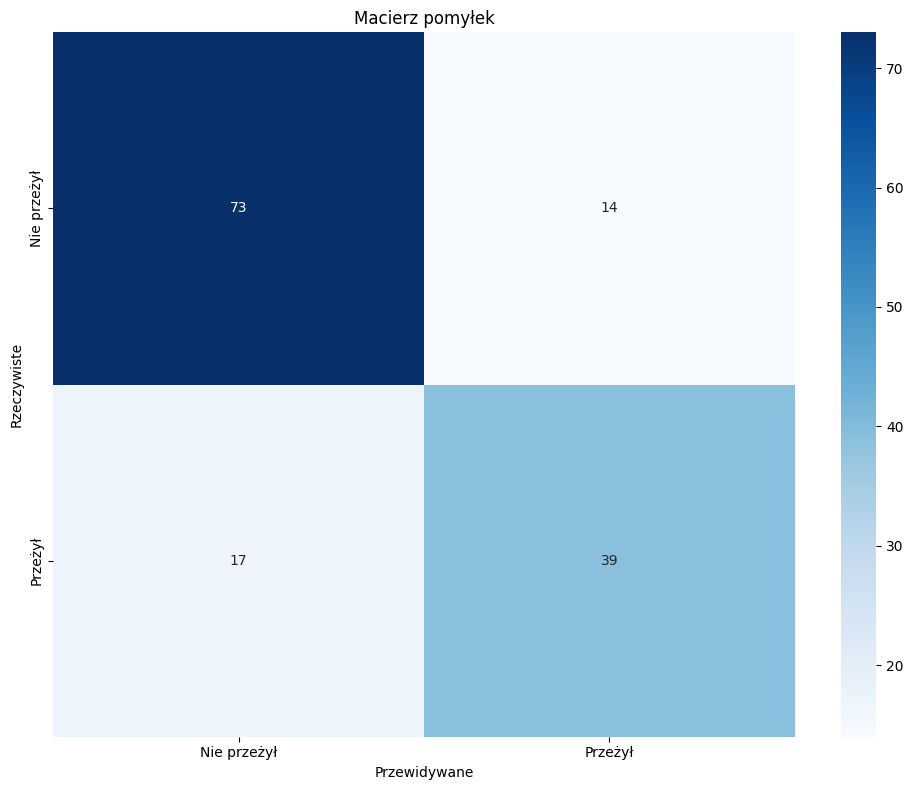

In [45]:
plt.figure(figsize=(10,8))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Nie przeżył', 'Przeżył'],
    yticklabels=['Nie przeżył', 'Przeżył']
)
plt.title('Macierz pomyłek')
plt.xlabel('Przewidywane')
plt.ylabel('Rzeczywiste')
plt.tight_layout()
plt.show()

In [ ]:
# selected_features= [ 'who', 'pclass', 'age', 'fare_category']

In [46]:
print('Symulacja katastrofy Titanica - sprawdź czy byś przeżył!!')

while True:
  print('Wpisz "koniec", aby zakończyć')

  try:

    who_input= input('\nPodaj rodzaj pasażera (m/k/d):').lower()

    if who_input==('koniec'): break
    who= 1 if who_input=='k' else 0 if who_input=='m' else 2

    pclass_input= input('\nPodaj kalsę biletu (1/2/3): ')

    if pclass_input==('koniec'): break
    pclass= int(pclass_input)

    age_input= input('\nPodaj wiek: ')

    if age_input==('koniec'): break
    age= float(age_input)

    print('\nPrzedziały ceny biletów (1/2/3): ')
    print(f'Niska: do {fare_ranges[0]:.2f}')
    print(f'średnia: do {fare_ranges[0]:.2f} do {fare_ranges[1]:.2f}')
    print(f'Wysoka:od {fare_ranges[1]:.2f}')

    fare_input= input('\nPodaj kalsę biletu (1/2/3): ')

    if fare_input==('koniec'): break
    fare= int(fare_input)

    new_passenger= pd.DataFrame({
        'who': [who],
        'pclass': [pclass],
        'age': [age],
        'fare_category': [fare]
    })

    new_passenger_scaled= scaler.transform(new_passenger)
    prediction= model.predict(new_passenger_scaled)
    probability= model.predict_proba(new_passenger_scaled)

    print('Dla wprowadzonych danych, przewidziano następujący rezultat:')
    print('Czy według symulacji przeżyłbyś katastrofę?')
    if prediction[0]==1:
      print('Tak')
    else:
      print('Nie')
    print(f'Wyliczone w symulacji prawdopodobieństwo przeżycia: {probability[0][1]:.2f}')

  except ValueError:
    print('Wprowadź poprawne wartości!!!')

  except Exception as e:
    print(f'Wystąpił błąd: {e}')

Symulacja katastrofy Titanica - sprawdź czy byś przeżył!!
Wpisz "koniec", aby zakończyć

Podaj rodzaj pasażera (m/k/d):m

Podaj kalsę biletu (1/2/3): 3

Podaj wiek: 27

Przedziały ceny biletów (1/2/3): 
Niska: do 170.78
średnia: do 170.78 do 341.55
Wysoka:od 341.55

Podaj kalsę biletu (1/2/3): 1
Dla wprowadzonych danych, przewidziano następujący rezultat:
Czy według symulacji przeżyłbyś katastrofę?
Nie
Wyliczone w symulacji prawdopodobieństwo przeżycia: 0.12
Wpisz "koniec", aby zakończyć

Podaj rodzaj pasażera (m/k/d):koniec


In [47]:
print(who)

0


In [48]:
type(who)

int